In [539]:
import pandas as pd
import os, sys, re
import numpy as np
import torch.nn as nn
from sklearn.feature_selection import SelectKBest, f_regression
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import random
import copy
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from state_conditioning import (
    build_state_conditioned_inputs,
    build_ridge_oof_predictions as build_ridge_oof_predictions_state,
    extract_state_indices,
    StateConditionedResidualMLP,
)


# Import Dataset and Tidy

In [540]:
train_data = pd.read_csv("./data/covid.train.csv")
test_data = pd.read_csv("./data/covid.test.csv")

In [541]:
test_data

,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,shop.2,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2
0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,52.071090,8.624001,29.374792,5.391413,2.754804,19.695098,13.685645,24.747837,66.194950,44.873473
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,58.742461,21.720187,41.375784,9.450179,3.150088,22.075715,17.302077,23.559622,57.015009,38.372829
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,59.109045,20.123959,40.072556,8.781522,2.888209,23.920870,18.342506,24.993341,55.291498,38.907257
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.442267,16.083529,36.977612,5.199286,2.575347,21.073800,12.087171,18.608723,67.036197,43.142779
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,60.588783,19.503010,42.631236,11.549771,8.530551,15.896575,11.781634,15.065228,61.196518,43.574676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,56.762931,21.494159,44.202567,14.996865,2.291745,17.740003,12.822676,18.123344,60.417531,37.156229
889,889,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.888461,16.770893,37.373472,7.169675,2.631595,20.587449,15.960166,23.710310,58.758735,38.673787
890,890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.589848,16.761311,36.874822,11.046907,1.912310,16.800220,13.280423,22.423640,60.934851,43.122513
891,891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,57.966384,22.696669,45.350415,20.343487,2.385330,16.528265,15.092539,17.476063,54.862386,44.016255


In [542]:
train_data

,id,AL,AK,AZ,AR,CA,CO,CT,FL,GA,...,restaurant.2,spent_time.2,large_event.2,public_transit.2,anxious.2,depressed.2,felt_isolated.2,worried_become_ill.2,worried_finances.2,tested_positive.2
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.812411,43.430423,16.151527,1.602635,15.409449,12.088688,16.702086,53.991549,43.604229,20.704935
1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.682974,43.196313,16.123386,1.641863,15.230063,11.809047,16.506973,54.185521,42.665766,21.292911
2,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.593983,43.362200,16.159971,1.677523,15.717207,12.355918,16.273294,53.637069,42.972417,21.166656
3,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.576992,42.954574,15.544373,1.578030,15.295650,12.218123,16.045504,52.446223,42.907472,19.896607
4,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,22.091433,43.290957,15.214655,1.641667,14.778802,12.417256,16.134238,52.560315,43.321985,20.178428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2695,2695,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.090116,30.839219,7.849525,1.760094,14.617563,11.163213,18.742673,68.024690,38.920206,13.008853
2696,2696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.779264,30.617100,7.754800,1.780730,14.513419,11.281241,18.539741,67.855755,39.224244,12.725638
2697,2697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.961085,30.595194,7.744075,1.921828,14.160990,11.163526,18.702564,67.731162,38.740651,12.613441
2698,2698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,14.609582,30.420998,7.687974,1.992580,14.409427,11.330301,19.134697,67.795100,38.595125,12.477227


## Baseline 0
先用 sklearn 快速確認「資料整理 + 評估流程」都正確。

In [543]:
# 從 training dataset 中分離出 validation dataset
X = train_data.drop(columns=['id', 'tested_positive.2'])
y = train_data['tested_positive.2'] # day3 percentage
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 標準化
scaler = StandardScaler() # 建立一個「標準化器」
X_train_s = scaler.fit_transform(X_train)

# 沿用上方平均數與標準差來校正 val
X_val_s = scaler.transform(X_val)


# ------------------------------------
# baseline 0 (如果我們預測出來 day3 = day2，loss 會是多少？)
pred_b0 = X_val["tested_positive.1"].to_numpy(dtype=np.float64) 
loss_b0 = mean_squared_error(y_val, pred_b0)
print(f"MSE of baseline 0 (predict y3=y2): {loss_b0}")

MSE of baseline 0 (predict y3=y2): 1.0638112270372913


# Baseline 1
建立 Ridge MODEL（y = wx+b），alpha 是懲罰 ｗ 機制，讓 w 不要太大 -> alpha 越小，model 越接近線性模型，擬合更貼但更可能 overfit；alpha 越大，model 越保守較不容易 overfit


In [544]:
# 測試不同 alpha 的 model

best_alpha_loss = {"alpha":0, "loss":10}

for a in list(np.arange(0.01, 2.0001, 0.01)):
    model = Ridge(alpha=a)
    model.fit(X_train_s, y_train)
    pred = model.predict(X_val_s)
    loss = mean_squared_error(y_val, pred)
    if loss < best_alpha_loss["loss"] and loss < loss_b0:
        best_alpha_loss["alpha"] = a
        best_alpha_loss["loss"] = loss

print(f"best alpha: {best_alpha_loss['alpha']}, MSE of baseline 1: {best_alpha_loss['loss']}")

best alpha: 0.01, MSE of baseline 1: 0.9291660509752497


# PyTorch

### helper functions

In [545]:
def set_seed(seed: int, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# 下面開始是 current notebook 會用到的 helper。
def make_multi_loader(*tensors, batch_size: int, seed: int):
    """Build a reproducible DataLoader for training batches."""
    g = torch.Generator()
    g.manual_seed(seed)

    dataset = TensorDataset(*tensors)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=0,
    )


# Legacy flat helpers are kept for comparison; the active path now uses state_conditioning.StateConditionedResidualMLP.
def make_flat_mlp(input_dim, hidden=64, dropout=0.1, n_layers=2):
    """Build a flat MLP for the residual prediction head."""
    layers = []
    dim = input_dim
    for _ in range(max(1, n_layers)):
        layers.extend([
            nn.Linear(dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        ])
        dim = hidden
    layers.append(nn.Linear(dim, 1))
    net = nn.Sequential(*layers)
    nn.init.zeros_(net[-1].weight)
    nn.init.zeros_(net[-1].bias)
    return net


class FlatResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden=64, dropout=0.1, n_layers=2):
        super().__init__()
        self.net = make_flat_mlp(input_dim, hidden=hidden, dropout=dropout, n_layers=n_layers)

    def forward(self, x):
        return self.net(x)


def split_state_and_day_features(all_cols, state_count, day1_pos_col, baseline_col):
    """Split the fixed input layout into the state block and flat day columns.

    The first ``state_count`` columns are the state one-hot block. The remaining
    columns are candidate day features, except for two forced scalar columns that
    we keep outside feature selection: ``day1_pos_col`` and ``baseline_col``.
    """
    state_cols = all_cols[:state_count]
    day_feature_cols = [
        col for col in all_cols[state_count:]
        if col not in {day1_pos_col, baseline_col}
    ]
    return state_cols, day_feature_cols


def build_flat_selected_inputs(
    X_train,
    X_val,
    y_train,
    state_cols,
    day_feature_cols,
    day1_pos_col,
    baseline_col,
    k,
    select_state_block=False,
):
    """Build flat inputs with an optional state-block selection switch.

    If ``select_state_block`` is False, keep the state block intact and select
    only among the flat day columns. If it is True, state columns and day
    columns compete together inside SelectKBest.
    """
    if select_state_block:
        candidate_cols = state_cols + day_feature_cols
        k = min(k, len(candidate_cols))

        selector = SelectKBest(score_func=f_regression, k=k)
        selector.fit(X_train[candidate_cols], y_train)
        selected_feature_cols = [
            col for col, keep in zip(candidate_cols, selector.get_support()) if keep
        ]

        feature_scaler = StandardScaler()
        feature_train_s = feature_scaler.fit_transform(X_train[selected_feature_cols]).astype(np.float32)
        feature_val_s = feature_scaler.transform(X_val[selected_feature_cols]).astype(np.float32)

        day1_pos_scaler = StandardScaler()
        day1_pos_train_raw = X_train[[day1_pos_col]].to_numpy(dtype=np.float32)
        day1_pos_val_raw = X_val[[day1_pos_col]].to_numpy(dtype=np.float32)
        day1_pos_train_s = day1_pos_scaler.fit_transform(day1_pos_train_raw).astype(np.float32)
        day1_pos_val_s = day1_pos_scaler.transform(day1_pos_val_raw).astype(np.float32)

        baseline_scaler = StandardScaler()
        base_train_raw = X_train[[baseline_col]].to_numpy(dtype=np.float32)
        base_val_raw = X_val[[baseline_col]].to_numpy(dtype=np.float32)
        base_train_in_s = baseline_scaler.fit_transform(base_train_raw).astype(np.float32)
        base_val_in_s = baseline_scaler.transform(base_val_raw).astype(np.float32)

        X_train_final_s = np.hstack([
            feature_train_s,
            day1_pos_train_s,
            base_train_in_s,
        ])
        X_val_final_s = np.hstack([
            feature_val_s,
            day1_pos_val_s,
            base_val_in_s,
        ])

        return {
            'selected_feature_cols': selected_feature_cols,
            'feature_scaler': feature_scaler,
            'state_scaler': None,
            'day_scaler': None,
            'day1_pos_scaler': day1_pos_scaler,
            'baseline_scaler': baseline_scaler,
            'X_train_final_s': X_train_final_s,
            'X_val_final_s': X_val_final_s,
        }

    k = min(k, len(day_feature_cols))

    selector = SelectKBest(score_func=f_regression, k=k)
    selector.fit(X_train[day_feature_cols], y_train)
    selected_feature_cols = [
        col for col, keep in zip(day_feature_cols, selector.get_support()) if keep
    ]

    state_scaler = StandardScaler()
    state_train_s = state_scaler.fit_transform(X_train[state_cols]).astype(np.float32)
    state_val_s = state_scaler.transform(X_val[state_cols]).astype(np.float32)

    day_scaler = StandardScaler()
    day_train_s = day_scaler.fit_transform(X_train[selected_feature_cols]).astype(np.float32)
    day_val_s = day_scaler.transform(X_val[selected_feature_cols]).astype(np.float32)

    day1_pos_scaler = StandardScaler()
    day1_pos_train_raw = X_train[[day1_pos_col]].to_numpy(dtype=np.float32)
    day1_pos_val_raw = X_val[[day1_pos_col]].to_numpy(dtype=np.float32)
    day1_pos_train_s = day1_pos_scaler.fit_transform(day1_pos_train_raw).astype(np.float32)
    day1_pos_val_s = day1_pos_scaler.transform(day1_pos_val_raw).astype(np.float32)

    baseline_scaler = StandardScaler()
    base_train_raw = X_train[[baseline_col]].to_numpy(dtype=np.float32)
    base_val_raw = X_val[[baseline_col]].to_numpy(dtype=np.float32)
    base_train_in_s = baseline_scaler.fit_transform(base_train_raw).astype(np.float32)
    base_val_in_s = baseline_scaler.transform(base_val_raw).astype(np.float32)

    X_train_final_s = np.hstack([
        state_train_s,
        day_train_s,
        day1_pos_train_s,
        base_train_in_s,
    ])
    X_val_final_s = np.hstack([
        state_val_s,
        day_val_s,
        day1_pos_val_s,
        base_val_in_s,
    ])

    return {
        'selected_feature_cols': selected_feature_cols,
        'feature_scaler': day_scaler,
        'state_scaler': state_scaler,
        'day_scaler': day_scaler,
        'day1_pos_scaler': day1_pos_scaler,
        'baseline_scaler': baseline_scaler,
        'X_train_final_s': X_train_final_s,
        'X_val_final_s': X_val_final_s,
    }


def build_ridge_oof_predictions(X_train_s, y_train_np, alpha, n_splits=5, seed=2025):
    """Build out-of-fold Ridge predictions for residual stacking.

    The main Ridge model is trained on the full training split later, but the
    residual target for the MLP should come from out-of-fold predictions so
    that the second stage does not learn from overly optimistic in-sample fit.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof_pred = np.zeros((X_train_s.shape[0], 1), dtype=np.float32)

    for fold_tr_idx, fold_oof_idx in kf.split(X_train_s):
        fold_model = Ridge(alpha=alpha)
        fold_model.fit(X_train_s[fold_tr_idx], y_train_np[fold_tr_idx].ravel())
        fold_pred = fold_model.predict(X_train_s[fold_oof_idx]).astype(np.float32).reshape(-1, 1)
        oof_pred[fold_oof_idx] = fold_pred

    full_model = Ridge(alpha=alpha)
    full_model.fit(X_train_s, y_train_np.ravel())
    return oof_pred, full_model

# Ridge main model + state-conditioned residual MLP

In [ ]:
X = train_data.drop(columns=['id', 'tested_positive.2'])
y_day3 = train_data['tested_positive.2']
y = y_day3 - train_data['tested_positive.1'] # residual target: day3 - day2
X_train, X_val, y_train, y_val, y_train_day3, y_val_day3 = train_test_split(X, y, y_day3, test_size=0.2, random_state=42)

# 目標仍然是預測 residual：day3 - day2。
# state 不再和 day features 一起競爭 selection；它會走 learned embedding conditioning。
# tested_positive（day1）和 tested_positive.1（day2 baseline）都強制保留在 day-window input 裡。
ALL_INPUT_COLS = X_train.columns.tolist()
STATE_COLS, DAY_FEATURE_COLS = split_state_and_day_features(
    ALL_INPUT_COLS,
    state_count=40,
    day1_pos_col='tested_positive',
    baseline_col='tested_positive.1',
)
DAY1_POS_COL = 'tested_positive'
BASELINE_COL = 'tested_positive.1'
SELECT_K = 12
STATE_EMBED_DIM = 8

print(f'total input columns = {len(ALL_INPUT_COLS)}')
print(f'state block columns = {len(STATE_COLS)}')
print(f'day feature columns available = {len(DAY_FEATURE_COLS)}')
print('state enters the model through a learned embedding prior and FiLM conditioning')
print(f'SelectKBest candidate day columns = {len(DAY_FEATURE_COLS)}')
print(f'SelectKBest k = {SELECT_K} columns')
print(f'forced scalar columns = {DAY1_POS_COL}, {BASELINE_COL}')

total input columns = 93
state block columns = 40
day feature columns available = 51
state enters the model through a learned embedding prior and FiLM conditioning
SelectKBest candidate day columns = 51
SelectKBest k = 40 columns
forced scalar columns = tested_positive, tested_positive.1


## Day Feature Selection Summary

In [547]:
print(f'state block columns = {len(STATE_COLS)}')
print(f'day feature columns available = {len(DAY_FEATURE_COLS)}')
print('state is handled separately by the embedding path')
print(f'SelectKBest keeps top k = {SELECT_K} day columns')
print(f'forced scalar columns = {DAY1_POS_COL}, {BASELINE_COL}')

state block columns = 40
day feature columns available = 51
state is handled separately by the embedding path
SelectKBest keeps top k = 40 day columns
forced scalar columns = tested_positive, tested_positive.1


## Selected Day Features

In [548]:
# Ridge 和 residual MLP 會共用這組 day-window input。
INPUT_DIM = min(SELECT_K, len(DAY_FEATURE_COLS)) + 2
INPUT_DIM

42

## Select and Normalize

In [549]:
conditioned_inputs = build_state_conditioned_inputs(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    state_cols=STATE_COLS,
    day_feature_cols=DAY_FEATURE_COLS,
    day1_pos_col=DAY1_POS_COL,
    baseline_col=BASELINE_COL,
    k=SELECT_K,
)

selected_feature_cols = conditioned_inputs['selected_feature_cols']
day_scaler = conditioned_inputs['day_scaler']
day1_pos_scaler = conditioned_inputs['day1_pos_scaler']
baseline_scaler = conditioned_inputs['baseline_scaler']
state_train_idx = conditioned_inputs['state_train_idx']
state_val_idx = conditioned_inputs['state_val_idx']
X_train_day_s = conditioned_inputs['X_train_day_s']
X_val_day_s = conditioned_inputs['X_val_day_s']

print('selected day feature columns:')
print(selected_feature_cols)
print(f'selected day feature columns = {len(selected_feature_cols)}')
print(f'state_train_idx shape = {state_train_idx.shape}')
print(f'X_train_day_s shape = {X_train_day_s.shape}')
print(f'X_val_day_s shape = {X_val_day_s.shape}')
print('state is now injected separately through a learned embedding prior + FiLM conditioning')


selected day feature columns:
['wearing_mask', 'travel_outside_state', 'work_outside_home', 'shop', 'restaurant', 'spent_time', 'large_event', 'public_transit', 'anxious', 'depressed', 'felt_isolated', 'worried_become_ill', 'worried_finances', 'wearing_mask.1', 'travel_outside_state.1', 'work_outside_home.1', 'shop.1', 'restaurant.1', 'spent_time.1', 'large_event.1', 'public_transit.1', 'anxious.1', 'felt_isolated.1', 'worried_become_ill.1', 'worried_finances.1', 'cli.2', 'ili.2', 'wearing_mask.2', 'travel_outside_state.2', 'work_outside_home.2', 'shop.2', 'restaurant.2', 'spent_time.2', 'large_event.2', 'public_transit.2', 'anxious.2', 'depressed.2', 'felt_isolated.2', 'worried_become_ill.2', 'worried_finances.2']
selected day feature columns = 40
state_train_idx shape = (2160,)
X_train_day_s shape = (2160, 42)
X_val_day_s shape = (540, 42)
state is now injected separately through a learned embedding prior + FiLM conditioning


## Ridge Main Model and State-Conditioned Residual MLP

In [550]:
# Ridge 先負責 day-window 主預測，state-conditioned MLP 再學 residual correction。
X_train_day_t = torch.tensor(X_train_day_s, dtype=torch.float32)
X_val_day_t = torch.tensor(X_val_day_s, dtype=torch.float32)
state_train_idx_t = torch.tensor(state_train_idx, dtype=torch.long)
state_val_idx_t = torch.tensor(state_val_idx, dtype=torch.long)
ytr_day3_np = y_train_day3.to_numpy(dtype=np.float32).reshape(-1, 1)
yva_day3_np = y_val_day3.to_numpy(dtype=np.float32).reshape(-1, 1)
ytr_day3_t = torch.tensor(ytr_day3_np, dtype=torch.float32)
yva_day3_t = torch.tensor(yva_day3_np, dtype=torch.float32)

seed = 2025

RIDGE_ALPHA = 0.3
ridge_oof_pred, ridge_model = build_ridge_oof_predictions_state(
    X_train_s=X_train_day_s,
    y_train_np=ytr_day3_np,
    alpha=RIDGE_ALPHA,
    n_splits=5,
    seed=seed,
)
ridge_va_pred = ridge_model.predict(X_val_day_s).astype(np.float32).reshape(-1, 1)
ridge_oof_pred_t = torch.tensor(ridge_oof_pred, dtype=torch.float32)
ridge_va_pred_t = torch.tensor(ridge_va_pred, dtype=torch.float32)
ytr_res_t = torch.tensor(ytr_day3_np - ridge_oof_pred, dtype=torch.float32)

print(f'Ridge main model alpha = {RIDGE_ALPHA}')
print(f'Ridge OOF train MSE before MLP = {mean_squared_error(ytr_day3_np.ravel(), ridge_oof_pred.ravel()):.4f}')
print(f'Ridge validation MSE before MLP = {mean_squared_error(yva_day3_np.ravel(), ridge_va_pred.ravel()):.4f}')



## ----------- model ----------- 
### initial parameters
lr = 0.0001
bs = 25
epochs = 1500
patience = 100
bad_count = 0
dropout = 0.2
hidden = 64
n_layers = 2
weight_decay = 0.01
train_hist, val_hist = [], []
best_epoch, best_state = None, None
best_va = float('inf')

set_seed(seed)
model = StateConditionedResidualMLP(
    num_states=len(STATE_COLS),
    day_input_dim=X_train_day_t.shape[1],
    state_emb_dim=STATE_EMBED_DIM,
    hidden=hidden,
    dropout=dropout,
    n_layers=n_layers,
)

### training
opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr/100)
train_loader = make_multi_loader(
    state_train_idx_t,
    X_train_day_t,
    ytr_res_t,
    batch_size=bs,
    seed=seed,
)

for ep in range(epochs):
    model.train()
    
    for batch in train_loader:
        state_b, x_b, yb_res = batch

        pred_res = model(state_b, x_b)
        loss = F.mse_loss(pred_res, yb_res)

        opt.zero_grad()
        loss.backward()
        opt.step()
    
    scheduler.step()

    with torch.no_grad():
        model.eval()

        p_tr_res = model(state_train_idx_t, X_train_day_t)
        p_va_res = model(state_val_idx_t, X_val_day_t)

        p_tr = ridge_oof_pred_t + p_tr_res
        p_va = ridge_va_pred_t + p_va_res

        tr_mse = F.mse_loss(p_tr, ytr_day3_t).item()
        va_mse = F.mse_loss(p_va, yva_day3_t).item()

        train_hist.append(tr_mse)
        val_hist.append(va_mse)
        print(f'epoch {ep + 1}: tr_mse={tr_mse:.4f}, va_mse={va_mse:.4f}')

        if va_mse < best_va - 1e-8:
            best_va = va_mse
            best_epoch = ep + 1
            best_state = copy.deepcopy(model.state_dict())
            bad_count = 0
        else:
            bad_count += 1
            if bad_count >= patience:
                print(f'Early stopping at epoch {ep + 1}. Best epoch = {best_epoch}, best va_mse = {best_va:.4f}')
                break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f'Restored best model from epoch {best_epoch} with best va_mse = {best_va:.4f}')



Ridge main model alpha = 0.3
Ridge OOF train MSE before MLP = 0.9751
Ridge validation MSE before MLP = 1.0093
epoch 1: tr_mse=0.9742, va_mse=1.0091
epoch 2: tr_mse=0.9732, va_mse=1.0087
epoch 3: tr_mse=0.9719, va_mse=1.0079
epoch 4: tr_mse=0.9708, va_mse=1.0076
epoch 5: tr_mse=0.9693, va_mse=1.0066
epoch 6: tr_mse=0.9676, va_mse=1.0065
epoch 7: tr_mse=0.9658, va_mse=1.0058
epoch 8: tr_mse=0.9642, va_mse=1.0060
epoch 9: tr_mse=0.9622, va_mse=1.0054
epoch 10: tr_mse=0.9602, va_mse=1.0058
epoch 11: tr_mse=0.9587, va_mse=1.0065
epoch 12: tr_mse=0.9570, va_mse=1.0058
epoch 13: tr_mse=0.9553, va_mse=1.0062
epoch 14: tr_mse=0.9534, va_mse=1.0060
epoch 15: tr_mse=0.9517, va_mse=1.0067
epoch 16: tr_mse=0.9499, va_mse=1.0074
epoch 17: tr_mse=0.9480, va_mse=1.0070
epoch 18: tr_mse=0.9468, va_mse=1.0072
epoch 19: tr_mse=0.9453, va_mse=1.0081
epoch 20: tr_mse=0.9441, va_mse=1.0086
epoch 21: tr_mse=0.9426, va_mse=1.0099
epoch 22: tr_mse=0.9410, va_mse=1.0107
epoch 23: tr_mse=0.9398, va_mse=1.0114
ep

KeyboardInterrupt: 

## Epoch Curve
訓練完成後，畫出 Ridge + state-conditioned residual MLP 的 day3 train / validation MSE。


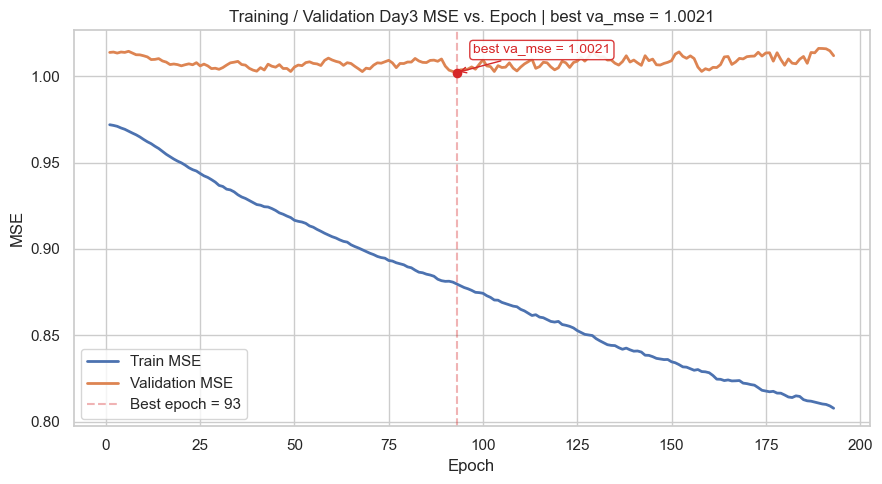

In [537]:
sns.set_theme(style="whitegrid")
epochs_ran = np.arange(1, len(train_hist) + 1)
best_epoch_plot = best_epoch if best_epoch is not None else int(np.argmin(val_hist) + 1)
best_va_mse = val_hist[best_epoch_plot - 1]

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, train_hist, label="Train MSE", linewidth=2)
plt.plot(epochs_ran, val_hist, label="Validation MSE", linewidth=2)
plt.axvline(best_epoch_plot, color="tab:red", linestyle="--", alpha=0.35, label=f"Best epoch = {best_epoch_plot}")
plt.scatter(best_epoch_plot, val_hist[best_epoch_plot - 1], color="tab:red", s=35, zorder=3)
plt.annotate(
    f'best va_mse = {best_va_mse:.4f}',
    xy=(best_epoch_plot, best_va_mse),
    xytext=(12, 14),
    textcoords='offset points',
    fontsize=10,
    color='tab:red',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='tab:red', alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='tab:red', lw=1),
)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title(f"Training / Validation Day3 MSE vs. Epoch | best va_mse = {best_va_mse:.4f}")
plt.legend()
plt.tight_layout()
plt.show()


# 實際預測、輸出 submission.csv，並上傳 kaggle

In [538]:
# 依照 data/sampleSubmission.csv 的格式產出 submission.csv
test_df = test_data.drop(columns=['id']).copy()
test_state = test_df[STATE_COLS]
assert list(test_state.columns) == STATE_COLS, 'Test state columns do not match training state block.'
test_state_idx = extract_state_indices(test_df, STATE_COLS)

test_selected_feature_cols = selected_feature_cols
assert list(test_df[test_selected_feature_cols].columns) == test_selected_feature_cols, 'Test feature columns do not match the selected training layout.'

test_day1_pos_raw = test_df[[DAY1_POS_COL]].to_numpy(dtype=np.float32)
test_day1_pos_in_s = day1_pos_scaler.transform(test_day1_pos_raw).astype(np.float32)
test_base_raw = test_df[[BASELINE_COL]].to_numpy(dtype=np.float32)
test_base_in_s = baseline_scaler.transform(test_base_raw).astype(np.float32)

test_day_s = day_scaler.transform(test_df[test_selected_feature_cols]).astype(np.float32)
test_day_window_s = np.hstack([test_day_s, test_day1_pos_in_s, test_base_in_s])
test_day_t = torch.tensor(test_day_window_s, dtype=torch.float32)
test_state_idx_t = torch.tensor(test_state_idx, dtype=torch.long)
ridge_test_pred = ridge_model.predict(test_day_window_s).astype(np.float32).reshape(-1, 1)
ridge_test_pred_t = torch.tensor(ridge_test_pred, dtype=torch.float32)
test_ids = test_data['id'].to_numpy()

model.eval()
with torch.no_grad():
    pred_res = model(test_state_idx_t, test_day_t)
    pred_day3 = (ridge_test_pred_t + pred_res).squeeze(1).cpu().numpy()

submission = pd.read_csv('./data/sampleSubmission.csv')
submission['id'] = test_ids
submission['tested_positive'] = pred_day3

submission.to_csv('submission.csv', index=False)

import subprocess
subprocess.run([
    'kaggle', 'competitions', 'submit',
    '-c', 'ml2021spring-hw1',
    '-f', 'submission.csv',
    '-m', 'Ridge+state-embedding/residual/SelectKBest(day)/k40'
], check=True)
submission.head()

100%|██████████| 11.9k/11.9k [00:00<00:00, 14.3kB/s]


Successfully submitted to ML2021Spring-hw1

,id,tested_positive
0,0,20.678957
1,1,2.230857
2,2,2.104262
3,3,10.732682
4,4,2.580404
